In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv("../Data/Merged/Prediction_all_with_sofr.csv")

kalshi_cols = [c for c in df.columns if c.startswith("kalshi_")]
poly_cols = [c for c in df.columns if c.startswith("polymarket_")]
sofr_cols = [c for c in df.columns if c.startswith("sofr_")]

print("Kalshi columns (probability buckets):")
for c in kalshi_cols:
    print(f"  {c}")

print(f"\nPolymarket columns (probability buckets):")
for c in poly_cols:
    print(f"  {c}")

print(f"\nSOFR columns:")
for c in sofr_cols:
    print(f"  {c}")

print(f"\nShape: {df.shape}")
print(f"Meetings: {sorted(df['decision_date'].unique())}")
df.head(3)

Kalshi columns (probability buckets):
  kalshi_C25
  kalshi_C50+
  kalshi_H0
  kalshi_H25
  kalshi_H50
  kalshi_H50+

Polymarket columns (probability buckets):
  polymarket_C25
  polymarket_C50
  polymarket_C50+
  polymarket_C75+
  polymarket_H0
  polymarket_H25
  polymarket_H25+
  polymarket_H50
  polymarket_H50+
  polymarket_H75

SOFR columns:
  sofr_method
  sofr_pre_rate
  sofr_post_rate
  sofr_expected_change
  sofr_p_minus_50
  sofr_p_minus_25
  sofr_p_0
  sofr_p_plus_25
  sofr_p_plus_50

Shape: (6012, 27)
Meetings: ['2023-02-01', '2023-03-22', '2023-05-02', '2023-06-12', '2023-06-13', '2023-07-25', '2023-09-20', '2023-10-31', '2023-12-12', '2023-12-13', '2024-01-31', '2024-03-18', '2024-04-30', '2024-06-12', '2024-07-31', '2024-09-18', '2024-11-07', '2024-12-18', '2025-01-29', '2025-03-19', '2025-05-07', '2025-06-18', '2025-07-30', '2025-09-17', '2025-10-29', '2025-12-10', '2026-01-28', '2026-03-18', '2026-04-29', '2026-06-17']


,decision_date,observed_day_pst,kalshi_C25,kalshi_C50+,kalshi_H0,kalshi_H25,kalshi_H50,kalshi_H50+,polymarket_C25,polymarket_C50,...,polymarket_H75,sofr_method,sofr_pre_rate,sofr_post_rate,sofr_expected_change,sofr_p_minus_50,sofr_p_minus_25,sofr_p_0,sofr_p_plus_25,sofr_p_plus_50
0,2023-02-01,2022-12-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.15,ois_anchor_long,0.042309,0.046596,0.004287,0.0,0.0,0.0,0.285097,0.714903
1,2023-02-01,2022-12-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.15,ois_anchor_short,0.042309,0.046486,0.004177,0.0,0.0,0.0,0.329273,0.670727
2,2023-02-01,2022-12-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.15,raw_futures_ois,0.042309,0.046486,0.004177,0.0,0.0,0.0,0.329273,0.670727


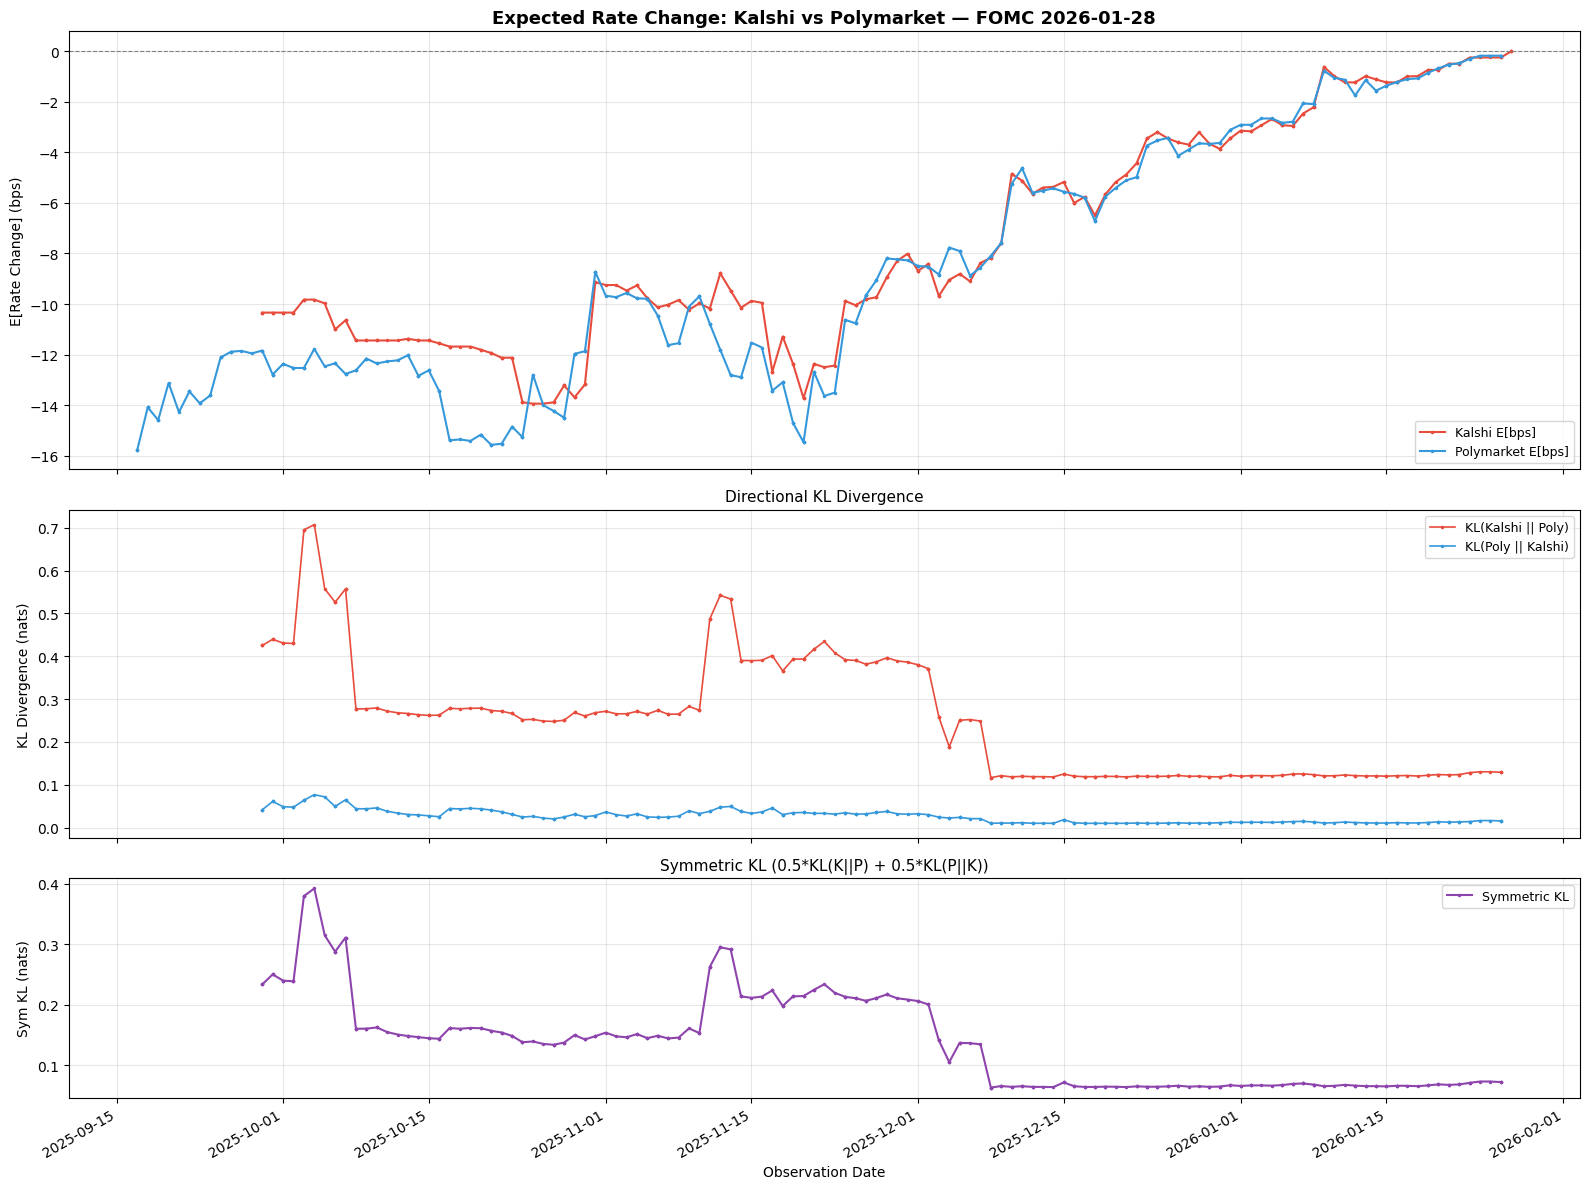


Stats (292 obs):
  Sym KL: mean=0.1385, max=0.3920, median=0.1427


In [6]:
import matplotlib.pyplot as plt
from scipy.special import rel_entr

df["observed_day_pst"] = pd.to_datetime(df["observed_day_pst"])

# Discrete outcome -> bps mapping for E[X] = sum(p_i * x_i)
kalshi_map = {
    "kalshi_C50+": -50, "kalshi_C25": -25, "kalshi_H0": 0,
    "kalshi_H25": 25, "kalshi_H50": 50, "kalshi_H50+": 50,
}
poly_map = {
    "polymarket_C75+": -75, "polymarket_C50+": -50, "polymarket_C50": -50,
    "polymarket_C25": -25, "polymarket_H0": 0, "polymarket_H25": 25,
    "polymarket_H25+": 25, "polymarket_H50": 50, "polymarket_H50+": 50,
    "polymarket_H75": 75,
}

def expected_change(row, col_map):
    total_prob = 0
    weighted = 0
    for col, bps in col_map.items():
        p = row.get(col)
        if pd.notna(p):
            p = float(p)
            weighted += p * bps
            total_prob += p
    if total_prob < 0.01:
        return np.nan
    return weighted / total_prob

meeting = "2026-01-28"
mdf = df[df["decision_date"] == meeting].sort_values("observed_day_pst").copy()
mdf["kalshi_exp_bps"] = mdf.apply(lambda r: expected_change(r, kalshi_map), axis=1)
mdf["poly_exp_bps"] = mdf.apply(lambda r: expected_change(r, poly_map), axis=1)

# KL divergence setup
kalshi_bucket_map = {
    "cut_50plus": ["kalshi_C50+"],
    "cut_25":     ["kalshi_C25"],
    "hold":       ["kalshi_H0"],
    "hike_25":    ["kalshi_H25"],
    "hike_50plus":["kalshi_H50+"],
}
poly_bucket_map = {
    "cut_50plus": ["polymarket_C50+"],
    "cut_25":     ["polymarket_C25"],
    "hold":       ["polymarket_H0"],
    "hike_25":    ["polymarket_H25"],
    "hike_50plus":["polymarket_H50+"],
}
EPS = 1e-8

def build_dist(row, bucket_map):
    p = np.array([row[cols].sum() for cols in bucket_map.values()], dtype=float)
    p = np.nan_to_num(p, nan=0.0)
    total = p.sum()
    if total < 1e-6:
        return None
    return p / total

def kl_divergence(p, q):
    p = np.clip(p, EPS, None)
    q = np.clip(q, EPS, None)
    return np.sum(rel_entr(p, q))

def symmetric_kl(p, q):
    return 0.5 * kl_divergence(p, q) + 0.5 * kl_divergence(q, p)

dates, kl_pq, kl_qp, kl_sym = [], [], [], []
for _, row in mdf.iterrows():
    p_k = build_dist(row, kalshi_bucket_map)
    q_p = build_dist(row, poly_bucket_map)
    if p_k is None or q_p is None:
        continue
    dates.append(row["observed_day_pst"])
    kl_pq.append(kl_divergence(p_k, q_p))
    kl_qp.append(kl_divergence(q_p, p_k))
    kl_sym.append(symmetric_kl(p_k, q_p))

kl_df = pd.DataFrame({"date": dates, "KL(K||P)": kl_pq, "KL(P||K)": kl_qp, "Sym KL": kl_sym})
kl_df.set_index("date", inplace=True)

# --- 3-panel plot ---
fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(16, 12), sharex=True,
                                     gridspec_kw={"height_ratios": [2, 1.5, 1]})

k_mask = mdf["kalshi_exp_bps"].notna()
p_mask = mdf["poly_exp_bps"].notna()
ax0.plot(mdf.loc[k_mask, "observed_day_pst"], mdf.loc[k_mask, "kalshi_exp_bps"],
         color="#e74c3c", linewidth=1.5, marker=".", markersize=3, label="Kalshi E[bps]")
ax0.plot(mdf.loc[p_mask, "observed_day_pst"], mdf.loc[p_mask, "poly_exp_bps"],
         color="#3498db", linewidth=1.5, marker=".", markersize=3, label="Polymarket E[bps]")
ax0.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax0.set_ylabel("E[Rate Change] (bps)")
ax0.set_title(f"Expected Rate Change: Kalshi vs Polymarket \u2014 FOMC {meeting}",
              fontsize=13, fontweight="bold")
ax0.legend(fontsize=9)
ax0.grid(True, alpha=0.3)

ax1.plot(kl_df.index, kl_df["KL(K||P)"], color="#e74c3c", linewidth=1.2,
         marker=".", markersize=3, label="KL(Kalshi || Poly)")
ax1.plot(kl_df.index, kl_df["KL(P||K)"], color="#3498db", linewidth=1.2,
         marker=".", markersize=3, label="KL(Poly || Kalshi)")
ax1.set_ylabel("KL Divergence (nats)")
ax1.set_title("Directional KL Divergence", fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.plot(kl_df.index, kl_df["Sym KL"], color="#8e44ad", linewidth=1.5,
         marker=".", markersize=3, label="Symmetric KL")
ax2.set_ylabel("Sym KL (nats)")
ax2.set_xlabel("Observation Date")
ax2.set_title("Symmetric KL (0.5*KL(K||P) + 0.5*KL(P||K))", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"\nStats ({len(kl_df)} obs):")
print(f"  Sym KL: mean={kl_df['Sym KL'].mean():.4f}, max={kl_df['Sym KL'].max():.4f}, median={kl_df['Sym KL'].median():.4f}")

KL(Kalshi | Poly) > KL(Poly | Kalshi) means poly fails to cover some of the mass in Kalshi distribution. Makes sense since poly has rate data for up to 75, which will take mass away. Basically this is cos of contract difference